# CS 195: Natural Language Processing
## Semantic Search with Embeddings

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ericmanley/s26-CS195NLP/blob/main/F4_3_SemanticSearchEmbeddings.ipynb)


## References

[Dot product (Wikipedia)](https://en.wikipedia.org/wiki/Dot_product)

[Cosine similarity (Wikipedia)](https://en.wikipedia.org/wiki/Cosine_similarity)

[Sentence-Transformers documentation](https://www.sbert.net/)

[all-MiniLM-L6-v2 model card](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2)



In [6]:
#import sys
#!{sys.executable} -m pip install torch tokenizers sentence-transformers matplotlib

## Let's think more about vectors for a bit

We previously talked about how thing computed by neural network nodes

$$y = w_nx_n+w_{n-1}x_{n-1}+\cdots+w_1x_1+b$$

could be thought of as vector operations 

$$y = \boldsymbol{w} \cdot \boldsymbol{x} + \boldsymbol{b}$$

where we have parameter vector $\boldsymbol{w} = [w_1, w_2, \ldots, w_n]$ and input vector $\boldsymbol{x} = [x_1, x_2, \ldots, x_n]$ and the operation we perform on them is the **dot product**
 


## Embeddings as vectors

We also talked about how the word embeddings we've come up with can be thought of vectors too, and we want to be able to think about how similar two embeddings are.

The dot product is one thing we could use. It more or less tells you how much of one vector *goes in the direction of another* and it is scaled by how long the vectors are. Here's a visualization ChatGPT made for me.

length of v1 = 3.1622776985168457
length of v2 = 4.8166375160217285
length of v3 = 2.8284270763397217
length of v4 = 2.2360680103302
dot(v1, v2) = 13.999999046325684
dot(v1, v3) = 8.0
dot(v1, v4) = -5.0


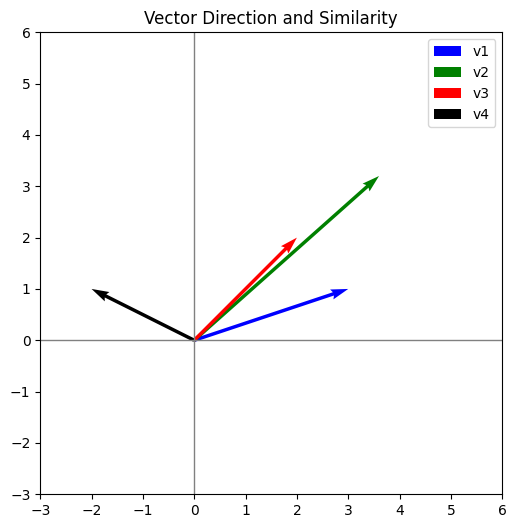

In [7]:
import torch
import matplotlib.pyplot as plt

# Two small 2D examples for intuition
v1 = torch.tensor([3.0, 1.0])
v2 = torch.tensor([3.6, 3.2])
v3 = torch.tensor([2.0, 2.0])
v4 = torch.tensor([-2.0, 1.0])


print('length of v1 =', torch.norm(v1).item())
print('length of v2 =', torch.norm(v2).item())
print('length of v3 =', torch.norm(v3).item())
print('length of v4 =', torch.norm(v4).item())

print('dot(v1, v2) =', torch.dot(v1, v2).item())
print('dot(v1, v3) =', torch.dot(v1, v3).item())
print('dot(v1, v4) =', torch.dot(v1, v4).item())


plt.figure(figsize=(6, 6))
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)
plt.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='blue', label='v1')
plt.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='green', label='v2')
plt.quiver(0, 0, v3[0], v3[1], angles='xy', scale_units='xy', scale=1, color='red', label='v3')
plt.quiver(0, 0, v4[0], v4[1], angles='xy', scale_units='xy', scale=1, label='v4')
plt.xlim(-3, 6)
plt.ylim(-3, 6)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.title('Vector Direction and Similarity')
plt.show()

## Cosine Similarity

For embeddings, the *length* of a vector isn't usually as important as its direction. 
* **direction** often encodes semantic relationships - words with similar meanings appear in the same direction
* **magnitude** is more random or picks up on things like word frequency

So, instead, we often measure similarity by calculating the cosine of the angle between them, which is just their dot product divided by the product of the vector lengths - so it removes the magnitude. If $\theta$ is the angle between two vectors,

$$cos \theta = \frac{\boldsymbol{a} \cdot \boldsymbol{b}}{\| \boldsymbol{a} \| \| \boldsymbol{b} \|}$$

where $\| \boldsymbol{a} \|$ denotes the length of the vector

In [8]:
def cosine(a, b):
    return torch.dot(a, b) / (torch.norm(a) * torch.norm(b))

print('cos(v1, v2) =', cosine(v1, v2).item())
print('cos(v1, v3) =', cosine(v1, v3).item())
print('cos(v1, v4) =', cosine(v1, v4).item())


cos(v1, v2) = 0.9191449880599976
cos(v1, v3) = 0.8944271802902222
cos(v1, v4) = -0.7071067690849304


## Semantic Search

**Semantic Search** is where you look for similarity between a query and set of documents based on embedding similarity. 

**Example query:** *pet animals*

**Example documents:**
* *Dogs and cats are common household pets.*
* *Stocks and bonds are common investment tools.*
* ...
  
We would want the search to return a hit for the first document even though it doesn't share the same words. 
* A traditional term-based search wouldn't find it

In [9]:
documents = [
    "Dogs and cats are common household pets.",
    "Kittens and puppies both need regular veterinary care.",
    "Sharks and whales live in the ocean.",
    "Coral reefs are delicate ocean ecosystems.",
    "Basketball teams practice shooting and defense.",
    "Soccer players train stamina and passing.",
    "Stocks and bonds are common investment tools.",
    "Inflation can affect interest rates and loan costs.",
    "Neural networks learn patterns from data.",
    "Transformers use attention to model language.",
    "Retrieval systems rank documents by relevance.",
    "Embedding vectors can capture semantic similarity."
]

query = "pet animals",



## A possible Semantic Search algorithm

Following what we did last time

1. **Tokenize documents**
2. **Train embeddings** from skip-gram pairs
3. **Pool each document** to one vector (take the average of all the word/token vectors)
4. **Tokenize + pool the query** to one vector
5. **Compute cosine similarities** between query vector and all document vectors
6. **Return documents with highest similarity**

Some problems: 
* We won't see good results from our small corpus - *we should use pre-trained embeddings* from a big corpus
* This kind of pooling (mean pooling) gives us the average over token embeddings, and we lose any benefits from word order - *we should pick a pre-trained embedding model that works on a sentence/document level instead of on each token*

## SentenceTransformer

`SentenceTransformer` is a pretrained model designed to output one embedding vector for an entire sentence (or short paragraph).

It uses a *Transformer* instead of a fully connected neural network like we used for word embeddings. We'll get into the details of Transformers in a few weeks.



## Group Discussion

Take a look at the sentence transformer `all-MiniLM-L6-v2` here: https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2

Be prepared to share anything interesting you find out about this model.

## Example

first load the SentenceTransformer and then create embeddings for documents and query.

In [11]:
from sentence_transformers import SentenceTransformer

st_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

documents = [
    "Dogs and cats are common household pets.",
    "Kittens and puppies both need regular veterinary care.",
    "Sharks and whales live in the ocean.",
    "Coral reefs are delicate ocean ecosystems.",
    "Basketball teams practice shooting and defense.",
    "Soccer players train stamina and passing.",
    "Stocks and bonds are common investment tools.",
    "Inflation can affect interest rates and loan costs.",
    "Neural networks learn patterns from data.",
    "Transformers use attention to model language.",
    "Retrieval systems rank documents by relevance.",
    "Embedding vectors can capture semantic similarity."
]

query = "pet animals"

doc_embeddings = st_model.encode(documents, convert_to_tensor=True)
query_embedding = st_model.encode(query, convert_to_tensor=True)

print(query_embedding)



/home/evan/evan-drake/cs-195/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 681.51it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tensor([-5.2146e-03,  3.2586e-02,  5.6227e-02,  7.2145e-02, -1.0486e-01,
        -1.3355e-02,  5.6139e-02, -5.1582e-02,  2.7358e-02,  2.9225e-02,
         3.9273e-03, -4.4161e-02, -4.4267e-02,  3.4908e-02, -7.5067e-03,
         4.7032e-03, -4.7423e-02,  6.6605e-03, -3.5892e-03, -1.4355e-02,
        -1.0325e-01,  8.2967e-03,  2.5431e-02,  1.0568e-02, -1.1685e-01,
         4.9062e-02, -5.7814e-02, -7.9445e-02, -6.6810e-03, -1.0829e-02,
        -3.1214e-02,  2.5127e-02, -6.4265e-03,  1.4319e-02, -3.0949e-02,
         2.1467e-02,  3.8225e-02, -2.8384e-02,  7.4146e-02,  4.3644e-02,
         9.3276e-03, -7.5342e-02,  2.7668e-02, -2.1406e-02, -6.3812e-02,
        -1.6091e-02, -7.0719e-02, -9.0057e-02,  2.0724e-02, -3.3988e-02,
         1.4591e-02,  5.4525e-02, -9.6310e-02,  2.2134e-02, -5.0477e-02,
        -1.0861e-01, -5.8510e-02, -5.1094e-03,  2.3184e-02, -3.4369e-02,
         6.9678e-02,  3.2459e-02,  4.0728e-02,  5.1207e-02,  2.4998e-02,
        -1.8658e-02, -5.9444e-02,  5.0363e-02,  2.0

Calulating the cosine similarity between the query and each document

In [12]:
def cosine(a, b):
    return torch.dot(a, b) / (torch.norm(a) * torch.norm(b))

print("Query:", query)

for d_idx in range(len(documents)):
    doc_sim_score = cosine(query_embedding, doc_embeddings[d_idx])
    print(doc_sim_score.item(), documents[d_idx])
    

Query: pet animals
0.6324346661567688 Dogs and cats are common household pets.
0.46050551533699036 Kittens and puppies both need regular veterinary care.
0.2634986340999603 Sharks and whales live in the ocean.
0.09991715848445892 Coral reefs are delicate ocean ecosystems.
0.04547315835952759 Basketball teams practice shooting and defense.
0.007905818521976471 Soccer players train stamina and passing.
0.10622045397758484 Stocks and bonds are common investment tools.
-0.04670102894306183 Inflation can affect interest rates and loan costs.
0.10141069442033768 Neural networks learn patterns from data.
0.08317268639802933 Transformers use attention to model language.
0.033138297498226166 Retrieval systems rank documents by relevance.
0.054523080587387085 Embedding vectors can capture semantic similarity.


## Group Exercise

Try running with these queries
* marine life in sea water
* how to invest money
* models for natural language

Discuss how well the model performs for each

What do you think you'd need to do if the number of documents was so large that you couldn't keep the document vectors all in memory at the same time?


In [15]:
q1 = "marine life in sea water"
print("Query:", q1)
q1_embedding = st_model.encode(q1, convert_to_tensor=True)

for i, doc in enumerate(documents):
    doc_sim_score = cosine(q1_embedding, doc_embeddings[i])
    print(doc_sim_score.item(), doc)

Query: marine life in sea water
0.0686931237578392 Dogs and cats are common household pets.
0.05226023495197296 Kittens and puppies both need regular veterinary care.
0.6148670315742493 Sharks and whales live in the ocean.
0.49226969480514526 Coral reefs are delicate ocean ecosystems.
-0.07888981699943542 Basketball teams practice shooting and defense.
-0.02471310645341873 Soccer players train stamina and passing.
0.0077053518034517765 Stocks and bonds are common investment tools.
0.002083853119984269 Inflation can affect interest rates and loan costs.
0.04911408945918083 Neural networks learn patterns from data.
-0.04068349674344063 Transformers use attention to model language.
0.03370227292180061 Retrieval systems rank documents by relevance.
0.03626672178506851 Embedding vectors can capture semantic similarity.


In [20]:
q2 = "how to invest money"
print("Query:", q2)
q2_embedding = st_model.encode(q2, convert_to_tensor=True)

for i, doc in enumerate(documents):
    doc_sim_score = cosine(q2_embedding, doc_embeddings[i])
    print(doc_sim_score.item(), doc)

Query: how to invest money
0.02435482293367386 Dogs and cats are common household pets.
0.037863485515117645 Kittens and puppies both need regular veterinary care.
0.09171269834041595 Sharks and whales live in the ocean.
0.03865370899438858 Coral reefs are delicate ocean ecosystems.
-0.038190003484487534 Basketball teams practice shooting and defense.
0.03298630565404892 Soccer players train stamina and passing.
0.4519420266151428 Stocks and bonds are common investment tools.
0.1412900686264038 Inflation can affect interest rates and loan costs.
0.03248878940939903 Neural networks learn patterns from data.
-0.12183792889118195 Transformers use attention to model language.
-0.03079015202820301 Retrieval systems rank documents by relevance.
0.0253139641135931 Embedding vectors can capture semantic similarity.


In [19]:
q3 = "models for natural language"
print("Query:", q3)
q3_embedding = st_model.encode(q3, convert_to_tensor=True)

for i, doc in enumerate(documents):
    doc_sim_score = cosine(q3_embedding, doc_embeddings[i])
    print(doc_sim_score.item(), doc)

Query: models for natural language
0.08960790932178497 Dogs and cats are common household pets.
0.008329207077622414 Kittens and puppies both need regular veterinary care.
0.0604887455701828 Sharks and whales live in the ocean.
-0.004260405898094177 Coral reefs are delicate ocean ecosystems.
0.09385708719491959 Basketball teams practice shooting and defense.
0.07466539740562439 Soccer players train stamina and passing.
0.01487438753247261 Stocks and bonds are common investment tools.
0.06126769632101059 Inflation can affect interest rates and loan costs.
0.2540917992591858 Neural networks learn patterns from data.
0.3905753791332245 Transformers use attention to model language.
0.2796086370944977 Retrieval systems rank documents by relevance.
0.40667054057121277 Embedding vectors can capture semantic similarity.


## Practice with a larger dataset

I have a json file with course descriptions from Fall 2025 (sorry, I haven't had time to scrape the schedule for next semester yet!)

Here are a couple of ways you can load the data into your notebook

In [21]:
# load directly from github using the requests library
import requests
import json

response = requests.get("https://raw.githubusercontent.com/ericmanley/S26-CS195NLP/refs/heads/main/data/f25_course_information.json")
data = json.loads(response.text)

In [ ]:
# load it as a local file - maybe you need to put it in your Google Drive folder first if you are using Colab
import json

with open("data/f25_course_information.json") as datafile:
    data = json.load(datafile)

Let's look at a sample of the data

In [22]:
for d in data[:3]:
    print(d)

{'id': 213644, 'term': 'Fall 2025', 'course_number': 'ACCT 041', 'subject': 'Accounting', 'title': 'INTRODUCTION TO FINANCIAL ACCOUNTING', 'course_search_url': 'https://catalog.drake.edu/course-search/?details&srcdb=2024&code=ACCT%20041', 'prereq': 'Prerequisite(s): None', 'description': '\n\n    The elements of the financial statements, accounting for deferrals, the double-entry accounting system, internal control and cash, receivables and payables, inventory, operational assets, long-term debt, equity transactions, income measurement, and comprehensive treatment of the balance sheet, the income statement and the statement of cash flows.  Financial statement analysis will be integrated throughout the course.\n    \n\n', 'credit_hours': None, 'faculty': ['Joyce Njoroge'], 'attributes': ['Critical Thinking'], 'location': ['ALIB 0010'], 'times': ['Monday, Wednesday 0930-1045'], 'filename': 'course_213644.json'}
{'id': 214670, 'term': 'Fall 2025', 'course_number': 'ACCT 041', 'subject': '

## Applied Exploration

Perform semantic search on the course information dataset, returning the top 3 courses with course descriptions matching a query (like "Neural Network"). You might find the `torch.topk` function useful: https://docs.pytorch.org/docs/stable/generated/torch.topk.html

* Test your approach out on three queries of your choosing
* Describe the results you're getting. Does it seem to be matching the best courses for your queries?


In [52]:
ae_query = "Neural Network"
ae_query_embedding = st_model.encode(ae_query, convert_to_tensor=True)

descriptions = [d['description'] for d in data]
desc_embeddings = st_model.encode(descriptions, convert_to_tensor=True)

similarities = [*map(lambda d: cosine(ae_query_embedding, d), desc_embeddings)]

best_matches = sorted(zip(similarities, data), key=lambda x: x[0], reverse=True)

for i, (sim, match) in enumerate(best_matches[:8]):
    print(f"Match {i+1}: {match['course_number']} - {match['title'].strip()}")
    print(match['description'].strip(), '\n')

Match 1: CS 167 - MACHINE LEARNING
This course introduces approaches to developing computer programs that learn from data.  Both foundational and contemporary machine learning algorithms will be covered in the context of a variety of data and problem types.  Specific topics will vary but may include artificial neural networks, decision trees, instance-based learning, Bayesian learning, support vector machines, hidden Markov models, reinforcement learning, and natural language processing.  Students will develop their own implementations of the algorithms as well as utilize modern machine learning software and programming libraries.  Pre-requisite: CS 065 and (CS 066 or STAT 040). 

Match 2: CS 167 - MACHINE LEARNING
This course introduces approaches to developing computer programs that learn from data.  Both foundational and contemporary machine learning algorithms will be covered in the context of a variety of data and problem types.  Specific topics will vary but may include artificia